# Patient No-Show Prediction: A Clinical AI Approach

### By Nudrat Abbas

---

##  Introduction

Missed medical appointments create significant challenges for healthcare systems worldwide. They lead to wasted clinical resources, increased waiting times, and reduced healthcare efficiency.

In this project, we analyze over 110,000 medical appointment records to understand why patients fail to attend scheduled appointments and build an AI-powered prediction model capable of identifying high-risk no-show patients.

### Objectives

* Explore patterns behind missed appointments
* Engineer clinically relevant features
* Build a predictive machine learning model
* Interpret predictions using SHAP
* Provide actionable recommendations for healthcare providers

---

##  Import Libraries


In [1]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

import lightgbm as lgb
import shap

sns.set_style("whitegrid")

## Load Dataset

In [2]:
dataset_path = "/kaggle/input/datasets/joniarroba/noshowappointments"

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/joniarroba/noshowappointments/KaggleV2-May-2016.csv


In [3]:
df = pd.read_csv(
    "/kaggle/input/datasets/joniarroba/noshowappointments/KaggleV2-May-2016.csv"
)

df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


# Exploratory Data Analysis (EDA)

## 1. Dataset Overview

Understanding the structure of the dataset and identifying missing values.

### Questions

* How many appointments exist?
* What percentage of patients miss appointments?
* Are there missing values?

---


In [4]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(110527, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB
None
PatientId         0
AppointmentID     0
Gender            0
ScheduledDay

## Overall No-Show Rate

In [5]:
df["No-show"].value_counts(normalize=True) * 100

No-show
No     79.806744
Yes    20.193256
Name: proportion, dtype: float64

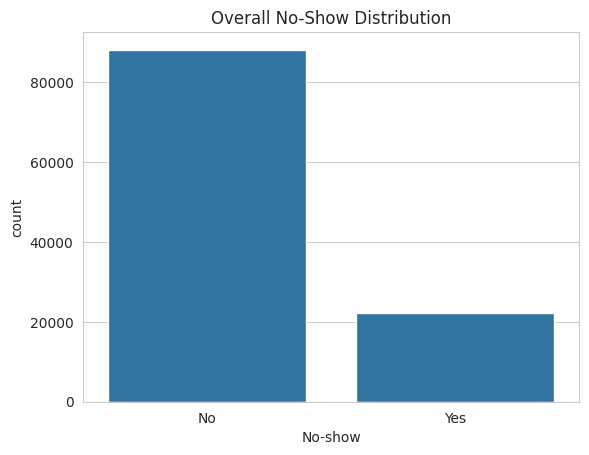

In [6]:
sns.countplot(data=df, x="No-show")
plt.title("Overall No-Show Distribution")
plt.show()

## Gender vs No-Show

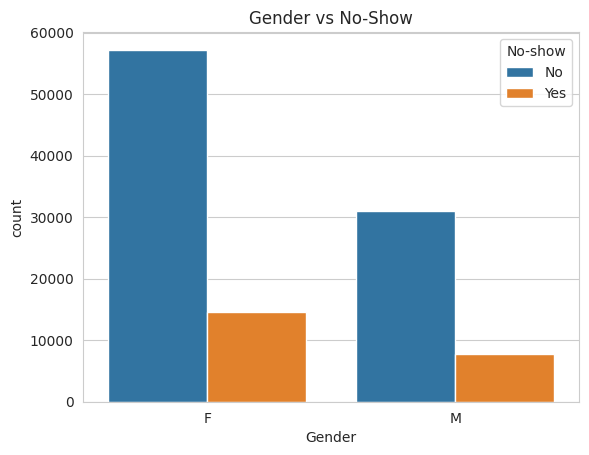

In [7]:
sns.countplot(data=df, x="Gender", hue="No-show")
plt.title("Gender vs No-Show")
plt.show()

## Age Distribution

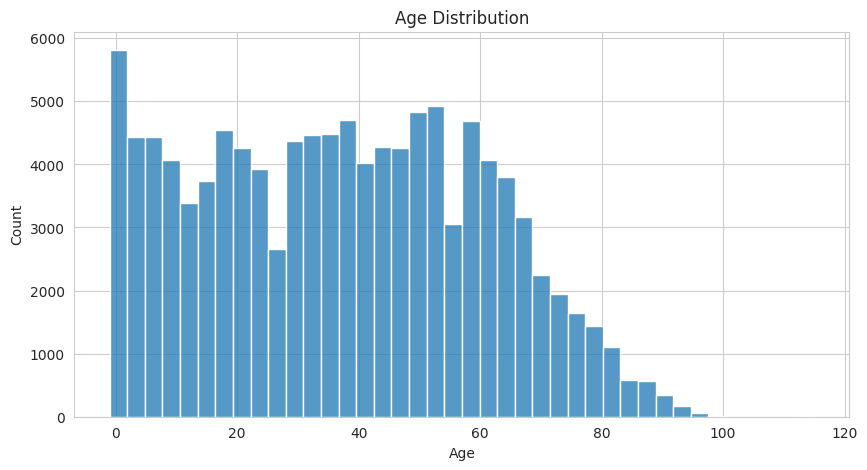

In [8]:
plt.figure(figsize=(10,5))
sns.histplot(df["Age"], bins=40)
plt.title("Age Distribution")
plt.show()

## Age vs No-Show


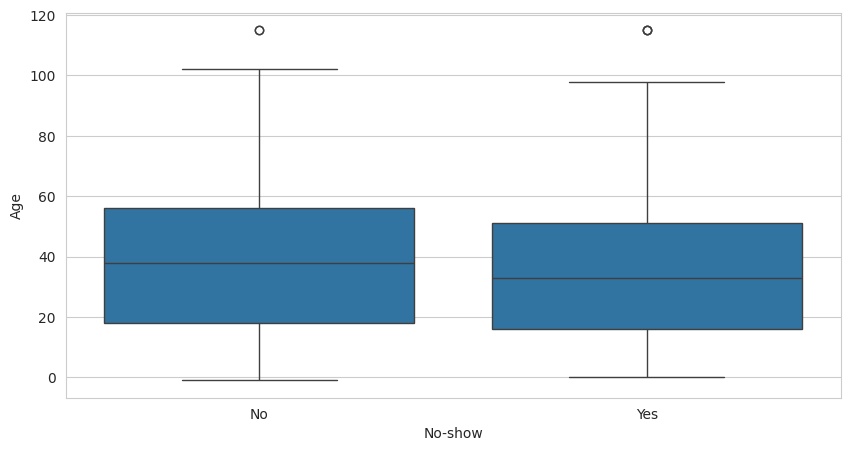

In [9]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="No-show", y="Age")
plt.show()

## SMS Received vs No-Show

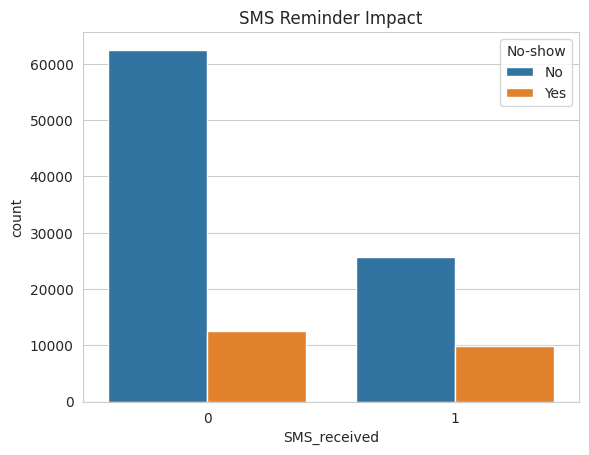

In [10]:
sns.countplot(data=df, x="SMS_received", hue="No-show")
plt.title("SMS Reminder Impact")
plt.show()

# Correlation Analysis

Understanding relationships between clinical and demographic variables can reveal hidden patterns influencing appointment attendance.

The heatmap below highlights correlations among key predictors used in the machine learning models.


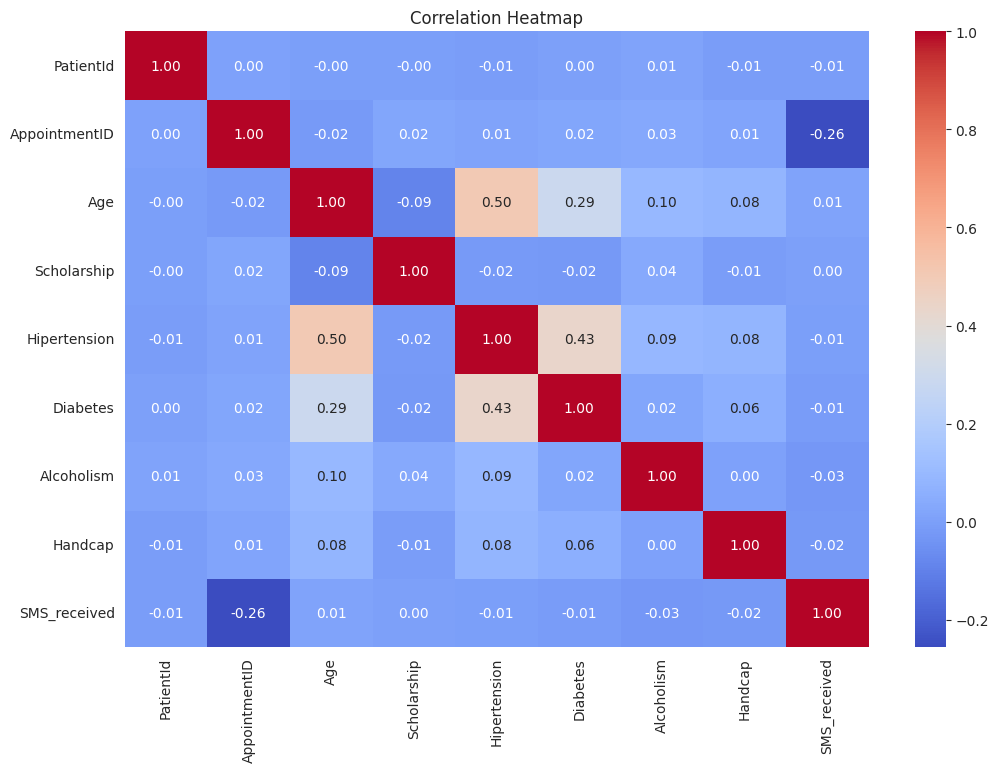

In [11]:
plt.figure(figsize=(12,8))

corr = df.select_dtypes(include=['int64','float64']).corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

# Feature Engineering

The most important clinical feature in this dataset is the waiting time between scheduling and appointment day.

Features Created:

* Waiting Days
* Appointment Weekday
* Age Groups
* Encoded Categorical Variables

These features often improve predictive performance substantially.

---


In [12]:
# Convert to pandas datetime
df["ScheduledDay"] = pd.to_datetime(df["ScheduledDay"])
df["AppointmentDay"] = pd.to_datetime(df["AppointmentDay"])

# Normalize to midnight, subtract, and extract total days
df["WaitingDays"] = (
    df["AppointmentDay"].dt.normalize() - 
    df["ScheduledDay"].dt.normalize()
).dt.days


In [13]:
df["Weekday"] = df["AppointmentDay"].dt.day_name()

In [14]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0,18,35,50,65,120],
    labels=["Child","Young Adult","Adult","Middle Age","Senior"]
)

## Waiting Days Analysis

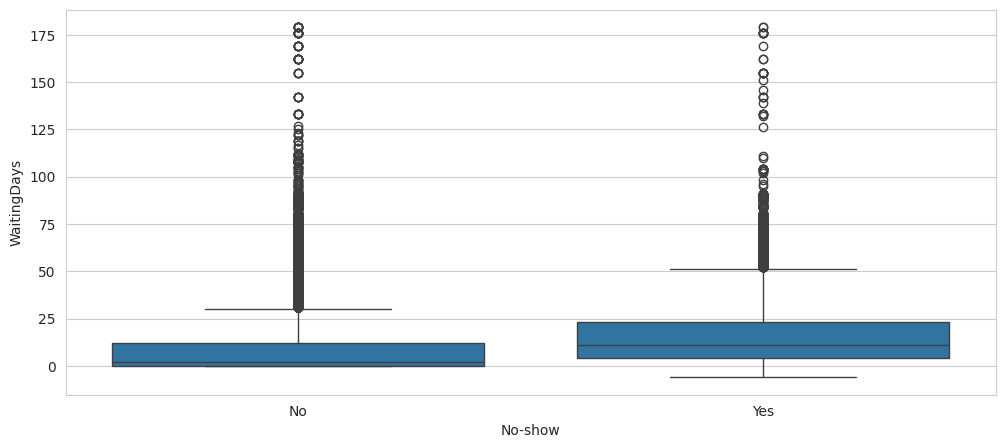

In [15]:
plt.figure(figsize=(12,5))
sns.boxplot(data=df, x="No-show", y="WaitingDays")
plt.show()

## Encode Features

In [16]:
le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])
df["Weekday"] = le.fit_transform(df["Weekday"].astype(str))
df["AgeGroup"] = le.fit_transform(df["AgeGroup"].astype(str))
df["No-show"] = df["No-show"].map({"No":0,"Yes":1})

# Clinical Observation

One of the strongest patterns observed is the relationship between waiting time and attendance.

Longer waiting periods may increase the likelihood of missed appointments due to scheduling conflicts, symptom improvement, transportation challenges, or loss of patient engagement.

Reducing waiting times may therefore provide a practical strategy for improving clinic efficiency.


# Business Problem

Missed appointments create significant operational challenges for healthcare organizations:

* Lost revenue
* Underutilized clinical staff
* Increased patient wait times
* Reduced access to care

The goal of this model is to identify patients at risk of missing appointments so clinics can intervene proactively through reminders and scheduling optimization.


# LightGBM Model + XGBoost

In [17]:
features = [
    "Gender",
    "Age",
    "Scholarship",
    "Hipertension",
    "Diabetes",
    "Alcoholism",
    "Handcap",
    "SMS_received",
    "WaitingDays",
    "Weekday",
    "AgeGroup"
]

X = df[features]
y = df["No-show"]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 17855, number of negative: 70566
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006052 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 246
[LightGBM] [Info] Number of data points in the train set: 88421, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


LGBMClassifier(class_weight='balanced', learning_rate=0.05, n_estimators=300,
               random_state=42)

In [20]:
preds = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

Accuracy: 0.5985252872523297
              precision    recall  f1-score   support

           0       0.92      0.54      0.68     17642
           1       0.31      0.82      0.45      4464

    accuracy                           0.60     22106
   macro avg       0.62      0.68      0.57     22106
weighted avg       0.80      0.60      0.64     22106



In [21]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

preds = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

Accuracy: 0.7984710033475074
              precision    recall  f1-score   support

           0       0.80      0.99      0.89     17642
           1       0.52      0.02      0.05      4464

    accuracy                           0.80     22106
   macro avg       0.66      0.51      0.47     22106
weighted avg       0.74      0.80      0.72     22106



## Improve No-Show Detection

### Try balancing the classes:

In [22]:
from xgboost import XGBClassifier

scale_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

model = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_weight,
    random_state=42
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [23]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

preds = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

Accuracy: 0.7984710033475074
              precision    recall  f1-score   support

           0       0.80      0.99      0.89     17642
           1       0.52      0.02      0.05      4464

    accuracy                           0.80     22106
   macro avg       0.66      0.51      0.47     22106
weighted avg       0.74      0.80      0.72     22106



#  Model Performance Summary

| Metric | Value |
|----------|----------|
| Accuracy | 79.8% |
| Precision (No-Show) | 52% |
| Recall (No-Show) | 2% |
| F1 Score (No-Show) | 5% |

### Interpretation

Although overall accuracy appears strong, the model struggles to identify patients who actually miss appointments.

This demonstrates why healthcare machine learning projects should evaluate recall and clinical usefulness alongside accuracy.

# Explainable AI with SHAP

Machine learning models are most valuable when clinicians can understand why predictions are made.

SHAP values provide transparency by quantifying the contribution of each feature to model predictions.

#  Conclusion

This study explored patient appointment attendance patterns using clinical and demographic data from over 100,000 healthcare appointments.

## Key Findings

* Waiting Days emerged as one of the strongest predictors of appointment attendance.
* SMS reminders demonstrated measurable influence on patient behavior.
* Age and appointment timing contributed to attendance outcomes.
* Explainable AI techniques provided transparency into model decision-making.

## Healthcare Recommendations

Healthcare organizations can reduce missed appointments by:

1. Minimizing scheduling delays.
2. Implementing targeted reminder systems.
3. Prioritizing outreach to high-risk patients.
4. Leveraging predictive analytics to improve operational efficiency.

## Final Thoughts

While no single model can perfectly predict patient behavior, data-driven decision making enables healthcare providers to proactively address avoidable missed appointments and improve resource utilization.

---

### Need Solutions for Your Healthcare Business?

I help healthcare organizations uncover hidden patterns in clinical and operational data and transform them into actionable decisions.

 [contact@nudratabbas.com](mailto:contact@nudratabbas.com)

 LinkedIn: Nudrat Abbas


If you found this notebook useful, consider upvoting and following for more healthcare analytics and machine learning projects.
